# 02 — Google Trends Data

Load, validate, and package the Google Trends search interest data collected by
`src/collect_google_trends.py`.

**Granularity note:** pytrends returns **monthly** data for time ranges > 5 years.
Our 15-year TIMEFRAME yields exactly 180 rows per (state, term) pair — one per
calendar month.  The "weekly → monthly aggregation" step is therefore a pass-through;
we simply rename `week_start` to `month` and treat each row as a month observation.

**Output:** `data/interim/google_trends_panel.parquet`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

RAW_DIR     = Path('../data/raw/google_trends')
INTERIM_DIR = Path('../data/interim')
FIG_DIR     = Path('../output/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TERMS = [
    'unemployment', 'file for unemployment', 'unemployment benefits',
    'jobs hiring', 'layoffs', 'resume',
]
STATES = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','DC','FL','GA','HI','ID',
    'IL','IN','IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO',
    'MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA',
    'RI','SC','SD','TN','TX','UT','VT','VA','WA','WV','WI','WY',
]

def slug(t): return t.replace(' ', '_')
def cpath(s, t): return RAW_DIR / f'{s}__{slug(t)}.csv'

## 1. Inventory check

In [2]:
results = []
for state in STATES:
    for term in TERMS:
        p = cpath(state, term)
        if p.exists() and p.stat().st_size > 100:
            df = pd.read_csv(p, parse_dates=['week_start'])
            nrows = len(df)
            dmin  = df['week_start'].min()
            dmax  = df['week_start'].max()
            zeros = int((df['interest'] == 0).sum())
        else:
            nrows, dmin, dmax, zeros = 0, None, None, 0
        results.append({'state':state,'term':term,'nrows':nrows,
                        'dmin':dmin,'dmax':dmax,'zeros':zeros})

inv = pd.DataFrame(results)

print(f"Expected pairs : {len(STATES)} states × {len(TERMS)} terms = {len(STATES)*len(TERMS)}")
print(f"Files found    : {(inv['nrows']>0).sum()}")
print(f"Missing/empty  : {(inv['nrows']==0).sum()}")
print(f"Row counts     : min={inv['nrows'].min()}  mean={inv['nrows'].mean():.1f}  max={inv['nrows'].max()}")
print()

# _FAILED.txt
failed_log = RAW_DIR / '_FAILED.txt'
if failed_log.exists():
    content = failed_log.read_text().strip()
    print(f"_FAILED.txt entries:\n{content}")
else:
    print("_FAILED.txt: not present (all pairs eventually succeeded)")

Expected pairs : 51 states × 6 terms = 306
Files found    : 306
Missing/empty  : 0
Row counts     : min=180  mean=180.0  max=180

_FAILED.txt entries:
CO	resume
CT	unemployment
IN	layoffs
LA	layoffs
LA	layoffs
LA	resume
ME	unemployment
ME	file for unemployment
ME	unemployment benefits
ME	jobs hiring
ME	layoffs
ME	resume
MD	unemployment
MD	file for unemployment
MD	unemployment benefits
MD	jobs hiring
LA	layoffs
LA	resume
ME	unemployment
ME	file for unemployment
ME	unemployment benefits
ME	jobs hiring
ME	layoffs
ME	resume
MD	unemployment
MD	file for unemployment
MD	unemployment benefits
MD	jobs hiring
MD	layoffs
MD	resume


In [3]:
# Flag problematic CSVs
low_cov  = inv[inv['nrows'] < 150]
all_zero = inv[inv['zeros'] == inv['nrows']]
short_dt = inv[inv['nrows'] > 0 & (
    (inv['dmin'] > pd.Timestamp('2010-06-01')) |
    (inv['dmax'] < pd.Timestamp('2024-06-01'))
)]

print(f"Low coverage (< 150 rows)     : {len(low_cov)}")
print(f"All-zero interest             : {len(all_zero)}")
print(f"Date range gaps               : {len(short_dt)}")

if len(low_cov): print(low_cov[['state','term','nrows']].to_string())
if len(all_zero): print(all_zero[['state','term']].to_string())
if len(short_dt): print(short_dt[['state','term','dmin','dmax']].to_string())

# Fraction of zeros per term (small states may have sparse signal)
print("\nMean zero-fraction per term:")
inv['zero_frac'] = inv['zeros'] / inv['nrows'].replace(0, np.nan)
print(inv.groupby('term')['zero_frac'].mean().round(3).sort_values(ascending=False).to_string())

Low coverage (< 150 rows)     : 0
All-zero interest             : 0
Date range gaps               : 306
    state                   term       dmin       dmax
0      AL           unemployment 2010-01-01 2024-12-01
1      AL  file for unemployment 2010-01-01 2024-12-01
2      AL  unemployment benefits 2010-01-01 2024-12-01
3      AL            jobs hiring 2010-01-01 2024-12-01
4      AL                layoffs 2010-01-01 2024-12-01
5      AL                 resume 2010-01-01 2024-12-01
6      AK           unemployment 2010-01-01 2024-12-01
7      AK  file for unemployment 2010-01-01 2024-12-01
8      AK  unemployment benefits 2010-01-01 2024-12-01
9      AK            jobs hiring 2010-01-01 2024-12-01
10     AK                layoffs 2010-01-01 2024-12-01
11     AK                 resume 2010-01-01 2024-12-01
12     AZ           unemployment 2010-01-01 2024-12-01
13     AZ  file for unemployment 2010-01-01 2024-12-01
14     AZ  unemployment benefits 2010-01-01 2024-12-01
15     AZ       

## 2. Load and stack all CSVs

In [4]:
chunks = []
for state in STATES:
    for term in TERMS:
        p = cpath(state, term)
        if p.exists() and p.stat().st_size > 100:
            df = pd.read_csv(p, parse_dates=['week_start'])
            chunks.append(df)

raw_panel = pd.concat(chunks, ignore_index=True)
raw_panel['week_start'] = pd.to_datetime(raw_panel['week_start'])
raw_panel['interest']   = pd.to_numeric(raw_panel['interest'], errors='coerce')

print('Stacked panel shape:', raw_panel.shape)
print(raw_panel.dtypes)
print()
print(raw_panel.head(4))

Stacked panel shape: (55080, 4)
week_start    datetime64[us]
term                     str
interest               int64
state_code               str
dtype: object

  week_start          term  interest state_code
0 2010-01-01  unemployment        14         AL
1 2010-02-01  unemployment        11         AL
2 2010-03-01  unemployment        12         AL
3 2010-04-01  unemployment        11         AL


## 3. Monthly aggregation

The data is already at monthly frequency (one row per month per state/term —
Google Trends returns monthly granularity for multi-year requests).
We rename `week_start` → `month` and extract `year` / `month_num` for convenience.

In [5]:
panel = (
    raw_panel
    .rename(columns={'week_start': 'month'})
    .assign(
        year      = lambda x: x['month'].dt.year,
        month_num = lambda x: x['month'].dt.month,
    )
    [['state_code', 'term', 'year', 'month_num', 'month', 'interest']]
    .sort_values(['state_code', 'term', 'month'])
    .reset_index(drop=True)
)

# Restrict to project window
panel = panel[(panel['month'] >= '2010-01-01') & (panel['month'] <= '2024-12-01')]

print('Panel shape:', panel.shape)
print(f"  states : {panel['state_code'].nunique()}")
print(f"  terms  : {panel['term'].nunique()}")
print(f"  months : {panel['month'].nunique()}  ({panel['month'].min().date()} — {panel['month'].max().date()})")
print()
print('Head:')
print(panel.head(8).to_string())
print()
print('Tail:')
print(panel.tail(4).to_string())

Panel shape: (55080, 6)
  states : 51
  terms  : 6
  months : 180  (2010-01-01 — 2024-12-01)

Head:
  state_code                   term  year  month_num      month  interest
0         AK  file for unemployment  2010          1 2010-01-01         0
1         AK  file for unemployment  2010          2 2010-02-01         0
2         AK  file for unemployment  2010          3 2010-03-01         0
3         AK  file for unemployment  2010          4 2010-04-01         0
4         AK  file for unemployment  2010          5 2010-05-01         0
5         AK  file for unemployment  2010          6 2010-06-01         0
6         AK  file for unemployment  2010          7 2010-07-01         0
7         AK  file for unemployment  2010          8 2010-08-01         0

Tail:
      state_code                   term  year  month_num      month  interest
55076         WY  unemployment benefits  2024          9 2024-09-01         0
55077         WY  unemployment benefits  2024         10 2024-10-01    

## 4. Validation

In [6]:
# Expected: 51 × 6 × 180 = 55,080
expected = 51 * 6 * 180
print(f"Expected rows: {expected:,}   Actual rows: {len(panel):,}")
assert abs(len(panel) - expected) / expected < 0.02, "Panel size off by >2% — check missing pairs"
print("✓ Panel size within 2% of expected")

# Coverage per (state, term)
coverage = (
    panel.groupby(['state_code','term'])['interest']
    .agg(n_months='count', n_nonzero=lambda x: (x>0).sum(), mean_int='mean')
    .round(2)
)
print(f"\nStates with full 180 months: {(coverage['n_months']==180).sum()} / {len(coverage)}")
print(f"Min months per pair: {coverage['n_months'].min()}")

# Zero-interest pairs — flagging for awareness
low_signal = coverage[coverage['n_nonzero'] < 30].sort_values('n_nonzero')
print(f"\nPairs with < 30 non-zero months ({len(low_signal)}):")
if len(low_signal):
    print(low_signal.to_string())
else:
    print("  None — all pairs have decent signal")

Expected rows: 55,080   Actual rows: 55,080
✓ Panel size within 2% of expected

States with full 180 months: 306 / 306
Min months per pair: 180

Pairs with < 30 non-zero months (9):
                                  n_months  n_nonzero  mean_int
state_code term                                                
SD         file for unemployment       180          5      1.32
ND         file for unemployment       180          6      1.43
AK         file for unemployment       180          8      1.83
WY         file for unemployment       180         13      2.62
VT         file for unemployment       180         16      2.68
HI         file for unemployment       180         23      2.81
WY         unemployment benefits       180         26      5.22
MT         file for unemployment       180         29      3.01
RI         file for unemployment       180         29      3.14


In [7]:
# Distribution of interest per term
print("Interest distribution by term (0–100 scale):")
dist = (
    panel.groupby('term')['interest']
    .describe(percentiles=[.25,.5,.75,.95])
    .round(1)
)
print(dist.to_string())

Interest distribution by term (0–100 scale):
                        count  mean   std   min   25%   50%   75%   95%    max
term                                                                          
file for unemployment  9180.0   5.1  10.9   0.0   0.0   3.0   5.0  16.0  100.0
jobs hiring            9180.0  54.5  20.5   0.0  40.0  56.0  69.0  86.0  100.0
layoffs                9180.0  19.6  17.3   0.0   9.0  16.0  26.0  54.0  100.0
resume                 9180.0  55.0  17.1  19.0  42.0  51.0  66.0  88.0  100.0
unemployment           9180.0  11.1  13.1   2.0   5.0   7.0  11.0  38.0  100.0
unemployment benefits  9180.0  10.4  13.6   0.0   4.0   6.0  12.0  36.0  100.0


## 5. Save to parquet

In [8]:
out_path = INTERIM_DIR / 'google_trends_panel.parquet'
panel.to_parquet(out_path, index=False)
print(f"Saved {out_path}  ({out_path.stat().st_size / 1e3:.0f} KB)")
print(f"Columns: {panel.columns.tolist()}")

Saved ../data/interim/google_trends_panel.parquet  (57 KB)
Columns: ['state_code', 'term', 'year', 'month_num', 'month', 'interest']


## 6. EDA charts

Saved 02_trends_eda_unemployment.png


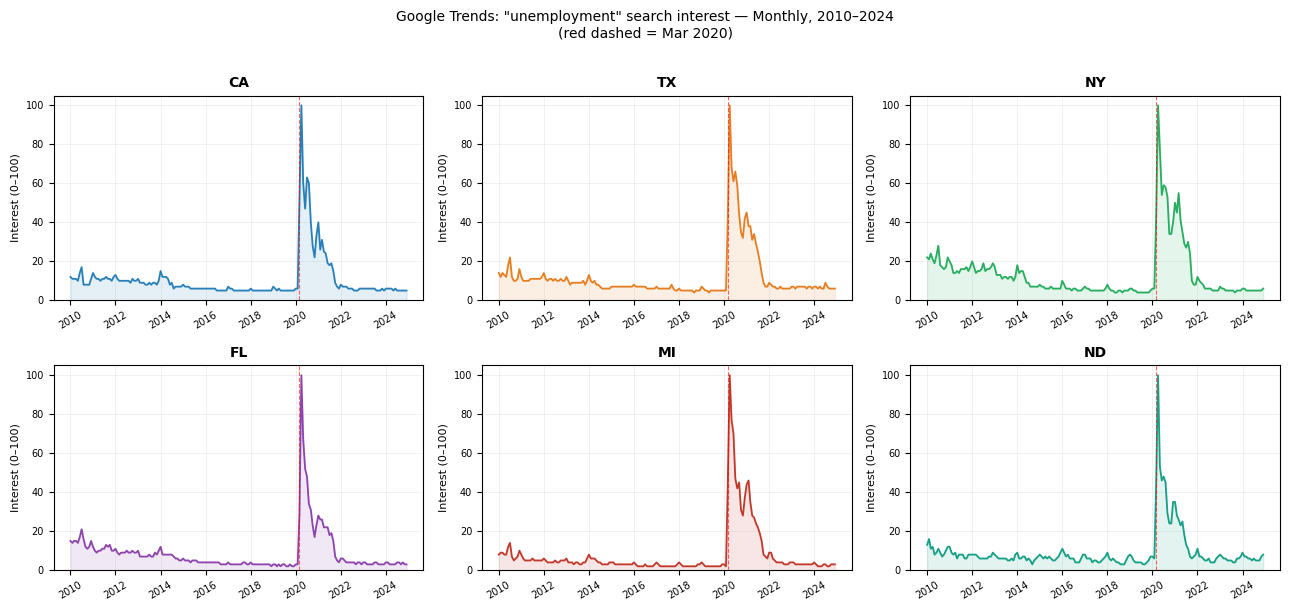

In [9]:
# ── Chart 1: 'unemployment' interest — 6 representative states ──────────────
STATES_6 = ['CA', 'TX', 'NY', 'FL', 'MI', 'ND']
COLORS    = ['#2980b9','#e67e22','#27ae60','#8e44ad','#c0392b','#16a085']

term_plot = 'unemployment'
sub = panel[(panel['term'] == term_plot) & (panel['state_code'].isin(STATES_6))]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=False)
axes = axes.flatten()

for ax, code, col in zip(axes, STATES_6, COLORS):
    s = sub[sub['state_code'] == code].sort_values('month')
    ax.plot(s['month'], s['interest'], color=col, linewidth=1.3)
    ax.fill_between(s['month'], s['interest'], alpha=0.12, color=col)
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linewidth=0.8,
               linestyle='--', alpha=0.6)
    ax.set_title(code, fontsize=10, fontweight='bold')
    ax.set_ylabel('Interest (0–100)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.25, linewidth=0.5)

fig.suptitle('Google Trends: "unemployment" search interest — Monthly, 2010–2024\n'
             '(red dashed = Mar 2020)', fontsize=10, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_trends_eda_unemployment.png', dpi=150, bbox_inches='tight')
print('Saved 02_trends_eda_unemployment.png')
plt.show()

Saved 02_trends_eda_layoffs.png


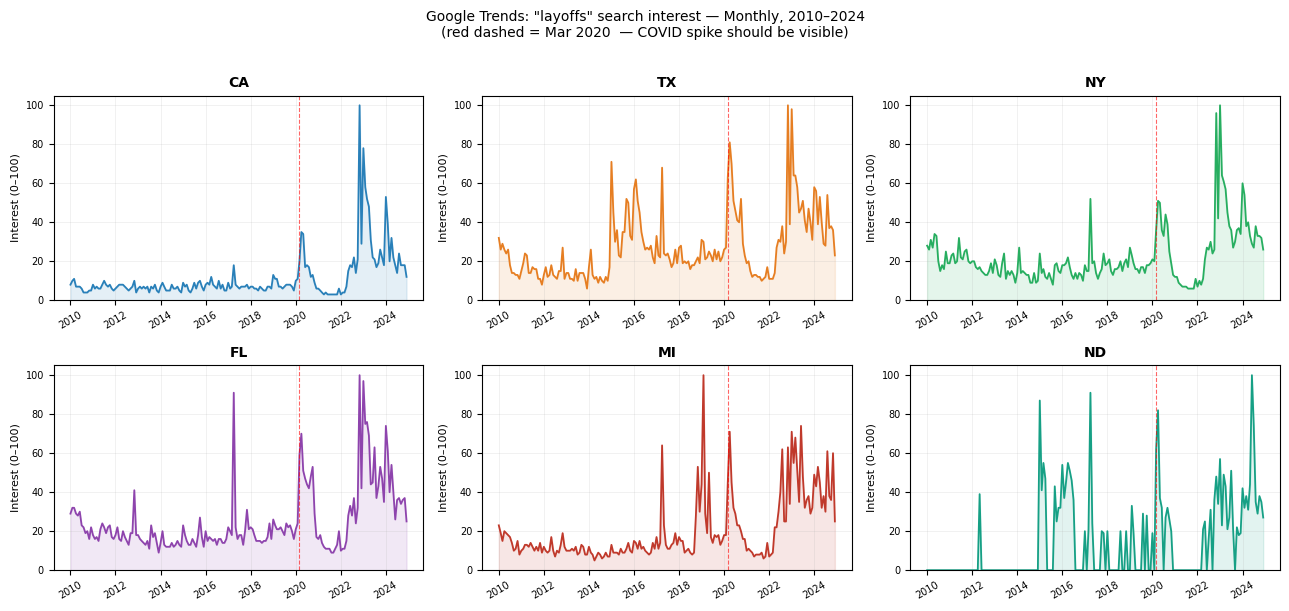

In [10]:
# ── Chart 2: 'layoffs' — COVID spike sanity check ────────────────────────────
term_plot = 'layoffs'
sub2 = panel[(panel['term'] == term_plot) & (panel['state_code'].isin(STATES_6))]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=False)
axes = axes.flatten()

for ax, code, col in zip(axes, STATES_6, COLORS):
    s = sub2[sub2['state_code'] == code].sort_values('month')
    ax.plot(s['month'], s['interest'], color=col, linewidth=1.3)
    ax.fill_between(s['month'], s['interest'], alpha=0.12, color=col)
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linewidth=0.8,
               linestyle='--', alpha=0.6)
    ax.set_title(code, fontsize=10, fontweight='bold')
    ax.set_ylabel('Interest (0–100)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.25, linewidth=0.5)

fig.suptitle('Google Trends: "layoffs" search interest — Monthly, 2010–2024\n'
             '(red dashed = Mar 2020  — COVID spike should be visible)', fontsize=10, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_trends_eda_layoffs.png', dpi=150, bbox_inches='tight')
print('Saved 02_trends_eda_layoffs.png')
plt.show()

Saved 02_trends_state_term_heatmap.png


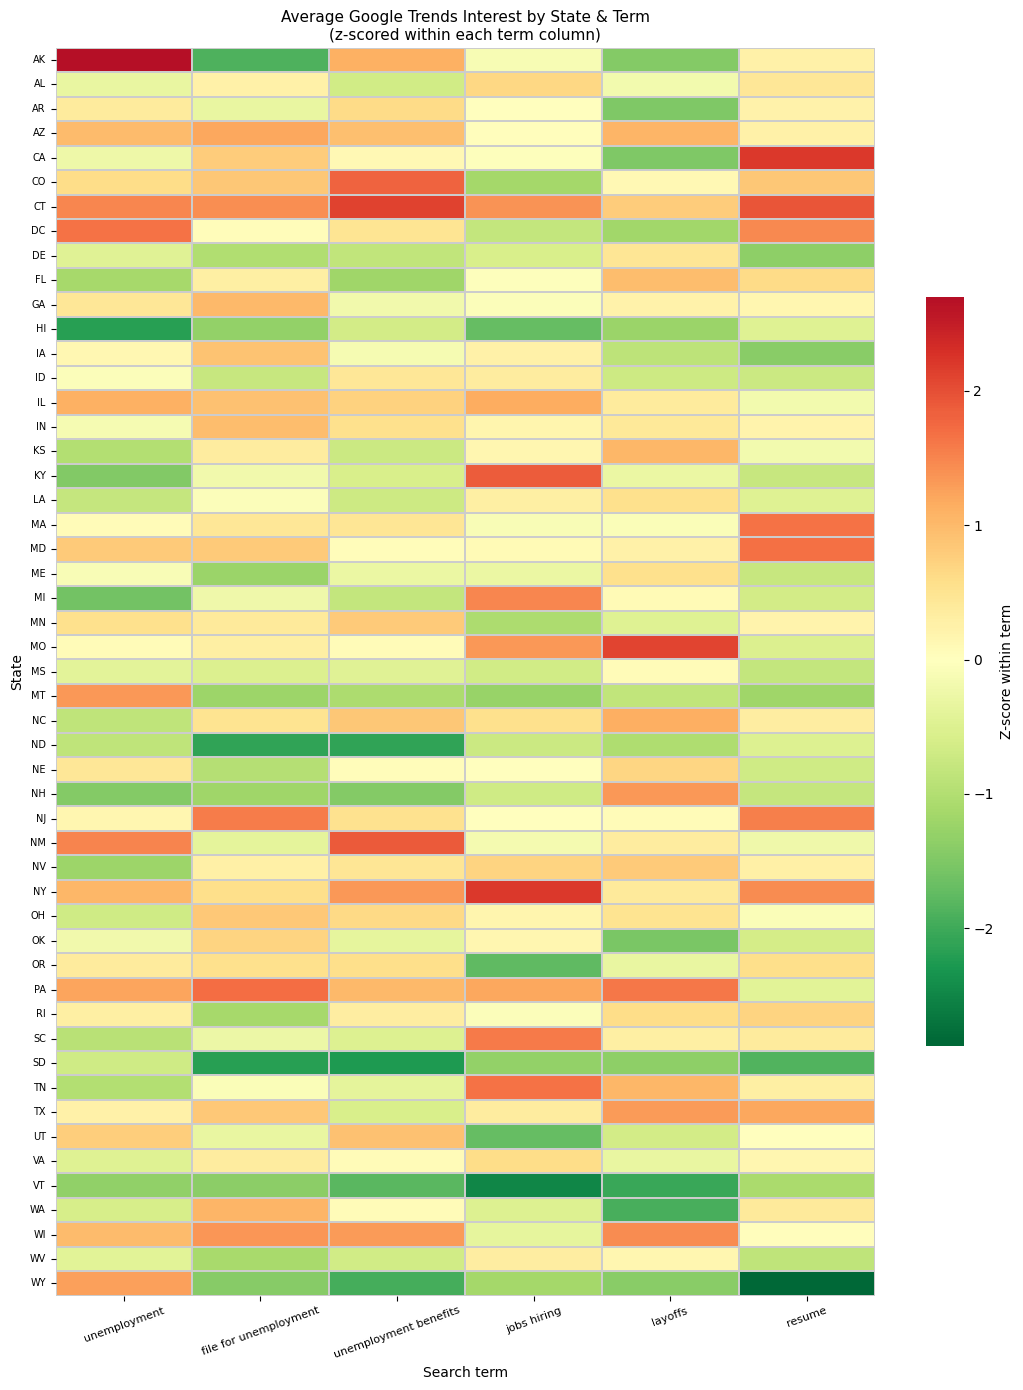

In [11]:
# ── Chart 3: Heatmap — average interest by (state, term), normed within term ─
avg = (
    panel.groupby(['state_code','term'])['interest']
    .mean()
    .unstack('term')    # rows=states, cols=terms
    [TERMS]             # consistent column order
)

# Z-score within each term column (within-term normalization)
avg_z = (avg - avg.mean()) / avg.std()

fig, ax = plt.subplots(figsize=(11, 14))
sns.heatmap(
    avg_z,
    ax=ax,
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.3,
    linecolor='#cccccc',
    annot=False,
    cbar_kws={'label': 'Z-score within term', 'shrink': 0.6},
)
ax.set_xlabel('Search term', fontsize=10)
ax.set_ylabel('State', fontsize=10)
ax.set_title('Average Google Trends Interest by State & Term\n(z-scored within each term column)',
             fontsize=11)
ax.tick_params(axis='x', labelsize=8, rotation=20)
ax.tick_params(axis='y', labelsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_trends_state_term_heatmap.png', dpi=150, bbox_inches='tight')
print('Saved 02_trends_state_term_heatmap.png')
plt.show()